# Detekcija pospanosti vozaca u realnom vremenu

Poredjenje transfer learning pristupa (**MobileNetV2** vs **ResNet50**, **frozen** vs **finetune**)
za klasifikaciju *pospan / budan*, sa postenom evaluacijom i real-time demo-om.

### Cilj projekta
- Pospanost vozaca je cest uzrok saobracajnih nesreca; cilj je detekcija sa kamere u realnom vremenu.
- Uporedjujemo 2 arhitekture (MobileNetV2, ResNet50) u 2 rezima (frozen, finetune) = **4 eksperimenta**.
- Naglasak nije samo na broju, nego na **postenoj metodologiji** (bez curenja podataka).



## 1. Podaci (DDD dataset)

- **41.793** slike, 2 klase: **Drowsy** (22.348) i **Non Drowsy** (19.445).
- Slike su vec tesno iseceni portreti lica (frejmovi iz snimaka vozaca).
- **28 razlicitih vozaca** - osoba je kodirana u imenu fajla (npr. `A0001` -> osoba `A`).

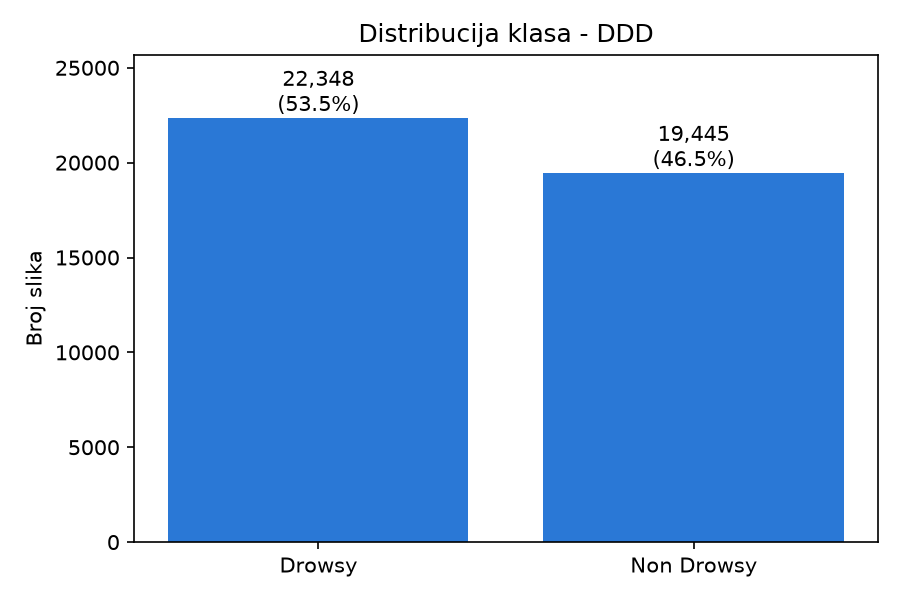

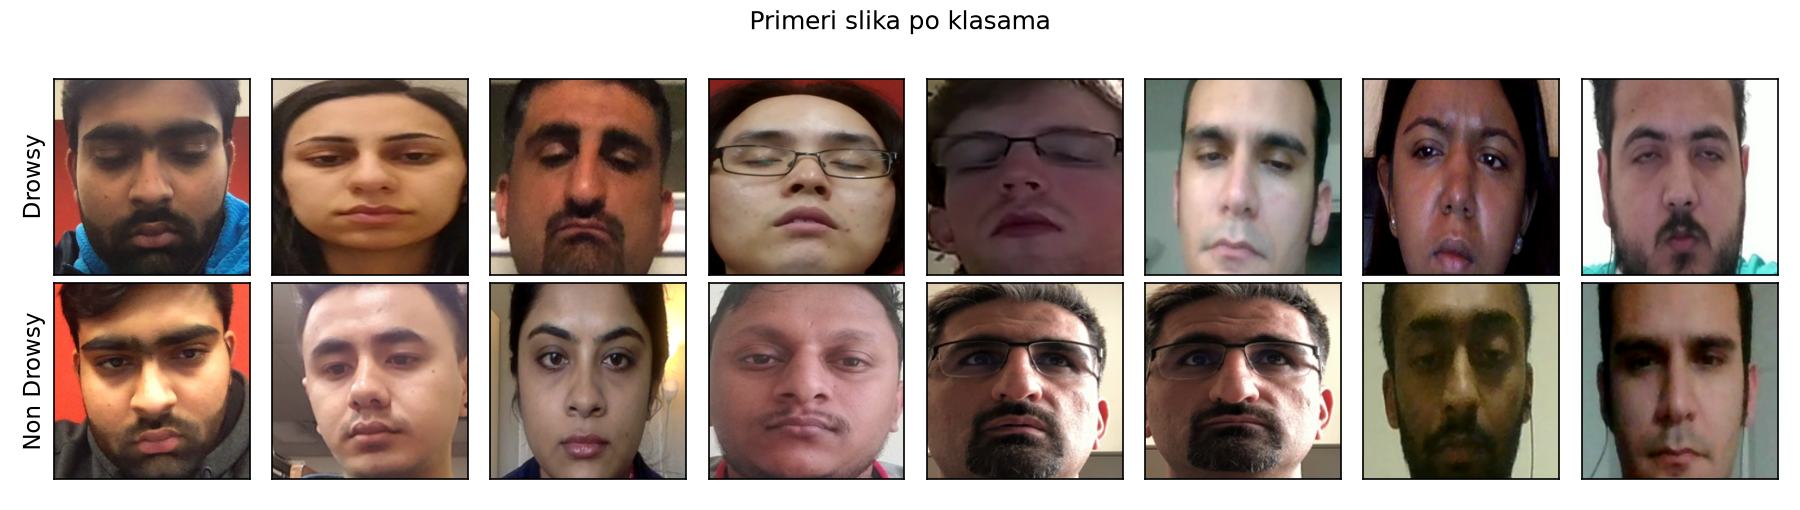

In [1]:
from IPython.display import Image, display
display(Image('report_assets/eda/class_distribution.png'))
display(Image('report_assets/eda/sample_images.png'))

Klase su priblizno izbalansirane, a slike su portreti lica (nema pozadine da se "vara").
Kljucno: svega **28 vozaca** - to ce se pokazati kao glavno ogranicenje.

## 2. Kljucni problem: curenje podataka (data leakage)

Slike su uzastopni frejmovi istih vozaca. Ako se podela train/test radi **nasumicno po slici**,
skoro identicni frejmovi iste osobe zavrse i u train i u test - model prepozna *osobu*, ne pospanost.

Ispravno je podeliti **po osobi** (subject-wise), tako da su vozaci u testu potpuno nevidjeni.
Da pokazemo efekat, isti model smo pustili sa obe podele

In [2]:
import json, pandas as pd
lk = json.load(open('report_assets/leakage.json'))
pd.DataFrame({
    'Podela': ['Per-image (curenje)', 'Subject-wise (posteno)'],
    'Accuracy (MobileNet finetune)': [f"{lk['per_image_leaky']*100:.2f} %",
                                      f"{lk['subject_wise']*100:.2f} %"],
})

,Podela,Accuracy (MobileNet finetune)
0,Per-image (curenje),99.96 %
1,Subject-wise (posteno),60.55 %


Ista arhitektura, isti podaci - jedina razlika je nacin podele: **~99.96 % vs ~60.55 %**.
Onih ~99 % koji se cesto vide u literaturi za ovaj dataset su posledica curenja.
Nas posten rezultat je ~60 %. Sve dalje koristi iskljucivo **subject-wise** podelu.

## 3. Metoda: 4 eksperimenta

Jedan kod, menja se samo `--model` i `--mode`:

| | frozen | finetune |
|---|---|---|
| **MobileNetV2** | backbone zamrznut, trenira se samo glava | + odmrznuta poslednja 2 bloka |
| **ResNet50** | backbone zamrznut, trenira se samo glava | + odmrznut `layer4` |

**Evaluacija:** subject-wise **5-fold cross-validacija** (StratifiedGroupKFold po osobi),
ugnjezden val skup za early stopping, a predikcije svih foldova se spoje
(svaka osoba je u testu tacno jednom).

In [3]:
from src.config import Config
from src.models import build_model
from src.utils import count_parameters
import pandas as pd

rows = []
for m in ['mobilenet', 'resnet']:
    for mode in ['frozen', 'finetune']:
        total, trainable = count_parameters(build_model(Config(model=m, mode=mode)))
        rows.append({'model': m, 'mode': mode,
                     'ukupno param': f'{total:,}', 'trenabilno': f'{trainable:,}'})
pd.DataFrame(rows)

,model,mode,ukupno param,trenabilno
0,mobilenet,frozen,"2,552,322","328,450"
1,mobilenet,finetune,"2,552,322","1,214,530"
2,resnet,frozen,"24,033,090","525,058"
3,resnet,finetune,"24,033,090","15,489,794"


Sva 4 eksperimenta dele isti pipeline:
`data.py` -> `models.py` -> `engine.py` -> `train.py` -> `evaluate.py`.

## 4. Podesavanja (hiperparametri)

Zajednicko za sve: optimizator **Adam**, batch **64**, ulaz **224x224**, do **30 epoha** uz
**early stopping** (patience 5), ImageNet normalizacija, 5-fold subject-wise CV.

Razlika po eksperimentu je **learning rate** i **sta se trenira** (cita se iz `configs/*.yaml`):

In [4]:
from src.config import build_config
from src.models import build_model
from src.utils import count_parameters
import pandas as pd

trenira = {'mobilenet': {'frozen': 'samo glava', 'finetune': 'glava + features[-2:]'},
           'resnet':    {'frozen': 'samo glava', 'finetune': 'glava + layer4'}}
rows = []
for name in ['mobilenet_frozen', 'mobilenet_finetune', 'resnet_frozen', 'resnet_finetune']:
    c = build_config(['--config', f'configs/{name}.yaml'])
    _, tr = count_parameters(build_model(c))
    rows.append({'eksperiment': name, 'lr': c.lr, 'trenira se': trenira[c.model][c.mode],
                 'trenabilno param': f'{tr:,}', 'dropout': c.dropout, 'weight_decay': c.weight_decay})
pd.DataFrame(rows)

,eksperiment,lr,trenira se,trenabilno param,dropout,weight_decay
0,mobilenet_frozen,0.0010,samo glava,"328,450",0.5,0.0
1,mobilenet_finetune,0.0001,glava + features[-2:],"1,214,530",0.5,0.0
2,resnet_frozen,0.0010,samo glava,"525,058",0.5,0.0
3,resnet_finetune,0.0001,glava + layer4,"15,489,794",0.5,0.0


**Zasto frozen ima veci lr (1e-3) a finetune manji (1e-4)?**
Kod *frozen* se trenira samo nova, nasumicno inicijalizovana glava - moze veci korak ucenja.
Kod *finetune* se doteruju i **pretrenirani** slojevi backbone-a, pa se koristi **manji** lr
da se ne unista ono sto je mreza vec naucila na ImageNet-u.

## 5. Rezultati (subject-wise 5-fold CV)

Uporedna tabela sva 4 eksperimenta: klasifikacione metrike (pozitivna klasa = Drowsy)
i prakticne metrike (broj parametara, velicina, brzina inferencije).

In [5]:
import json, pandas as pd
df = pd.DataFrame(json.load(open('report_assets/comparison.json')))
df = df[['experiment', 'accuracy', 'precision_drowsy', 'recall_drowsy',
         'f1_drowsy', 'total_params', 'size_mb', 'fps']]
df.columns = ['eksperiment', 'acc', 'prec', 'rec', 'f1', 'params', 'MB', 'FPS']
df

,eksperiment,acc,prec,rec,f1,params,MB,FPS
0,mobilenet_frozen,0.5653,0.5816,0.6664,0.6211,2552322,9.87,305.8
1,mobilenet_finetune,0.6035,0.6128,0.7021,0.6544,2552322,9.87,275.9
2,resnet_frozen,0.5959,0.5924,0.7829,0.6745,24033090,91.88,274.0
3,resnet_finetune,0.6476,0.6796,0.6451,0.6619,24033090,91.88,240.5


Najbolja tacnost: **resnet_finetune (0.648)**; najbolji F1: **resnet_frozen (0.674)**.
Svi rezultati su u postenom opsegu ~0.57-0.65 (ne nerealnih 99 %).

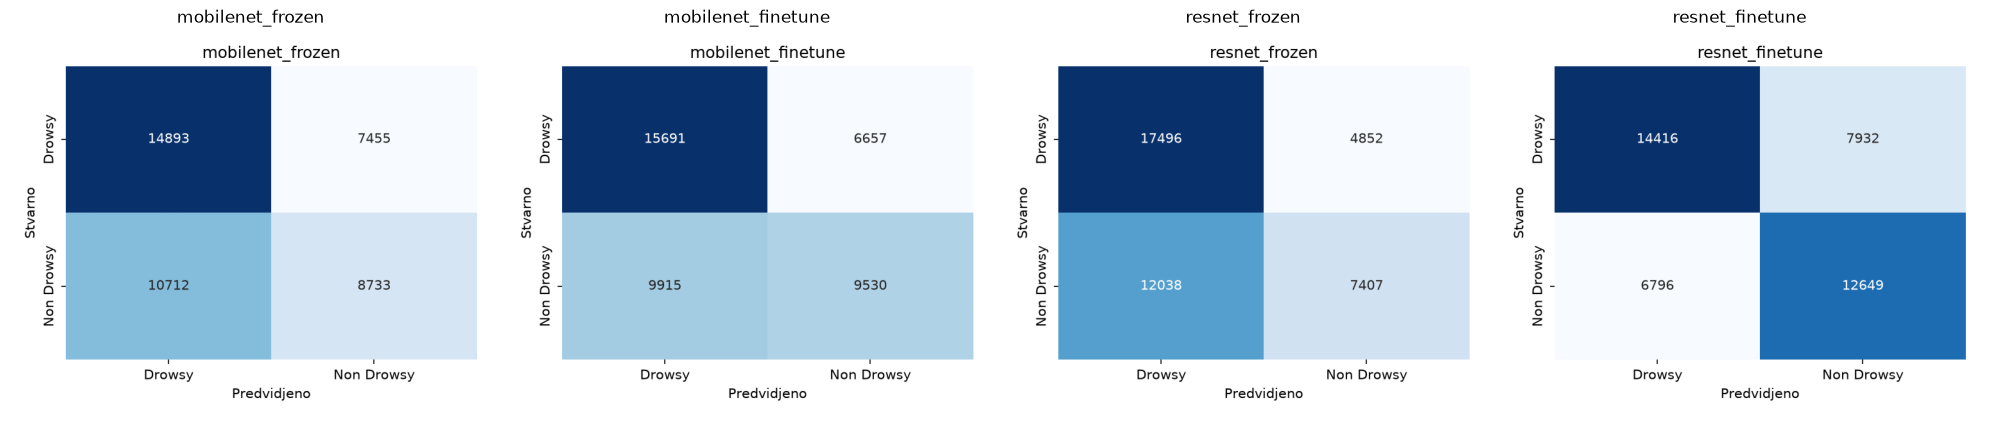

In [6]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg
exps = ['mobilenet_frozen', 'mobilenet_finetune', 'resnet_frozen', 'resnet_finetune']
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, e in zip(ax, exps):
    a.imshow(mpimg.imread(f'report_assets/confusion/{e}.png')); a.axis('off'); a.set_title(e)
plt.tight_layout(); plt.show()

## 6. Kriva ucenja i overfitting

Sve varijante brzo dostignu ~100 % na trening skupu, dok validacioni loss raste - overfitting. Model pamti trening-vozace, ali se to slabo prenosi na nove.

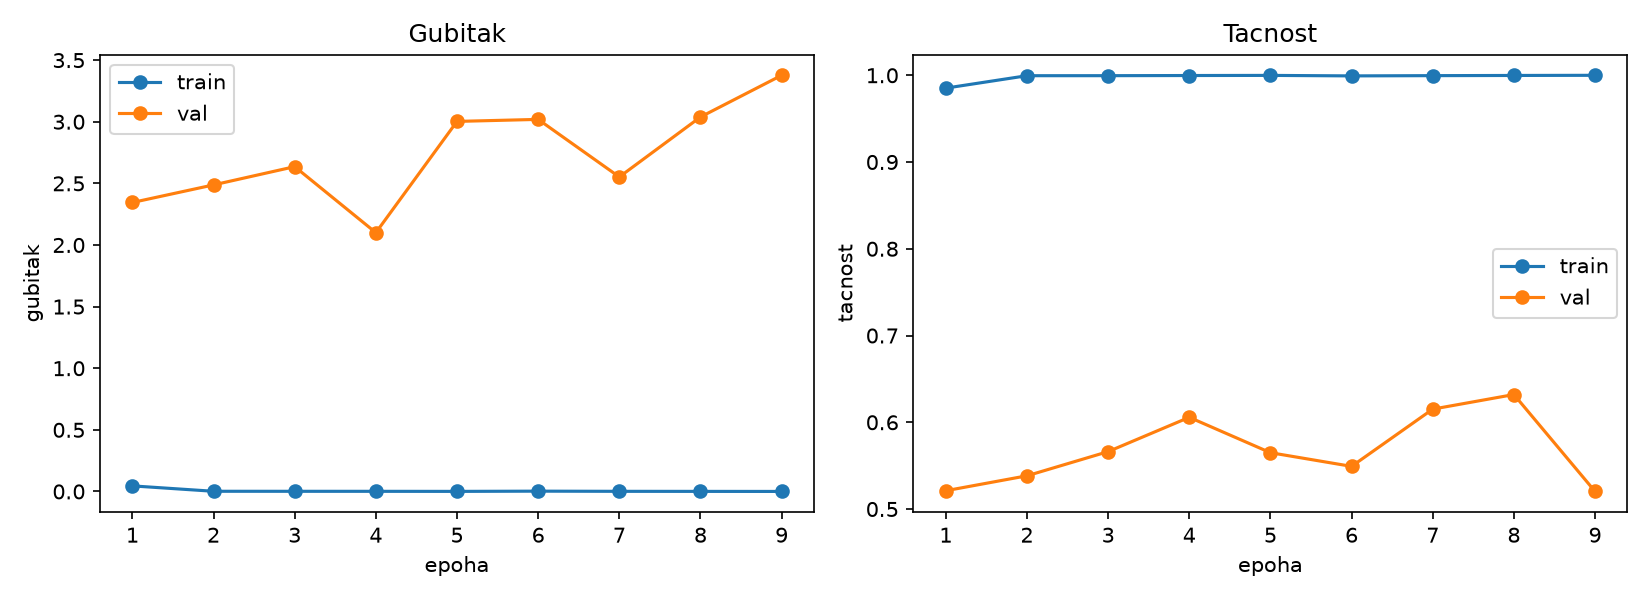

In [7]:
from IPython.display import Image
Image('report_assets/curves/mobilenet_finetune_fold0.png')

Train tacnost brzo skoci na skoro 100%, dok validaciona stoji na mestu - model je zapamtio trening-vozace, ali to znanje ne prenosi na nepoznate ljude. Ta razlika izmedju visoke trening i niske validacione tacnosti naziva se **generalizacioni jaz**, i upravo je ona prava mera koliko model generalizuje na nove vozace. Zato early stopping bira epohu sa najmanjim validacionim loss-om (ovde obicno vrlo rano).

## 7. Pokusaji poboljsanja (ablacije)

Da smanjimo jaz, probali smo redom (na MobileNet finetune): regularizaciju, jaku augmentaciju,
i **ROI oko ociju**. Za ROI koristimo **YuNet** detekciju lica (radi i sa zatvorenim ocima)
pa isecemo predeo ociju - ideja je da model gleda bas oci, glavni znak umora.

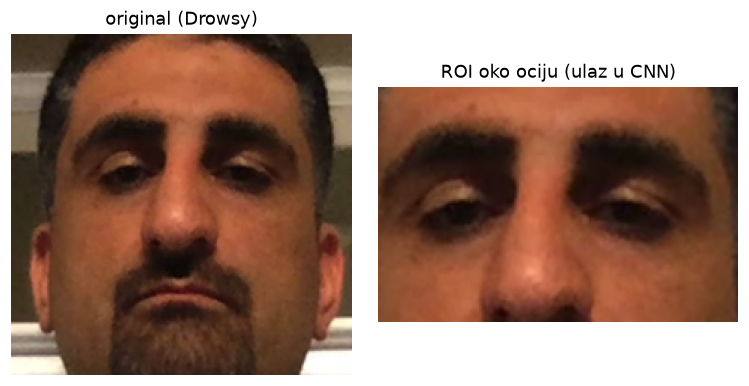

In [8]:
from IPython.display import Image
Image('report_assets/eye_crop/primeri.png')

Rezultati (test_acc_mean se cita iz `report_assets/ablations.json`, izvor je naveden u fajlu):

In [9]:
import json, pandas as pd
abl = json.load(open('report_assets/ablations.json'))
pd.DataFrame([{'Pokusaj': a['pokusaj'], 'Test acc': a['test_acc_mean']} for a in abl])

,Pokusaj,Test acc
0,Baseline (celo lice),0.6055
1,+ weight_decay + dropout,0.6049
2,+ jaka augmentacija,0.5669
3,Eye-ROI + grayscale + aug,0.5773


Nijedan pokusaj ne probija plafon (cak malo odmaze). Zakljucak: usko grlo je
**broj razlicitih vozaca (28)**, ne arhitektura ni hiperparametri.
Uklanjanje piksela ne pomaze jer i oci nose identitet osobe.

## 8. Kljucni nalaz: 10x manji model daje slicne rezultate

MobileNetV2 ima skoro **10x manje parametara i 10x manju velicinu** od ResNet50,
a postize uporediv F1 - i brzi je za real-time.

In [10]:
import json, pandas as pd
d = {r['experiment']: r for r in json.load(open('report_assets/comparison.json'))}
mob, res = d['mobilenet_finetune'], d['resnet_finetune']
pd.DataFrame({
    'metrika': ['parametri', 'velicina (MB)', 'FPS', 'F1 (Drowsy)', 'accuracy'],
    'MobileNetV2': [f"{mob['total_params']:,}", mob['size_mb'], mob['fps'], mob['f1_drowsy'], mob['accuracy']],
    'ResNet50':    [f"{res['total_params']:,}", res['size_mb'], res['fps'], res['f1_drowsy'], res['accuracy']],
})

,metrika,MobileNetV2,ResNet50
0,parametri,"2,552,322","24,033,090"
1,velicina (MB),9.87,91.88
2,FPS,275.9,240.5
3,F1 (Drowsy),0.6544,0.6619
4,accuracy,0.6035,0.6476


MobileNetV2 (~2.5M param, ~10 MB) je uporediv sa ResNet50 (~24M, ~92 MB) po F1.
Za real-time / laptop / edge, MobileNet je jasno bolji izbor.
Dodatno: **frozen je blizu finetune** - vecina vrednosti dolazi iz pretreniranih ImageNet
feature-a, ne iz opsirnog treninga.

## 9. Real-time demo (OpenCV)

Tok: kamera -> **YuNet** detekcija lica -> CNN klasifikacija -> ispis Drowsy/Awake sa procentom.
Predikcije se **vremenski uglacavaju** (prosek zadnjih N frejmova) da ne trepere -
odluku i dalje donosi CNN.

Istrenirani mobilenet model dolazi u repo-u (`assets/`), pa demo radi odmah posle `git clone`:

    python -m src.webcam --model assets/final_mobilenet_finetune.pt      # izlaz: 'q'

Demo radi uzivo na nepoznatoj osobi za jasne slucajeve
(siroko otvorene oci = budan, skoro zatvorene = pospan).

## 10. Zakljucak i buduci rad

**Zakljucci:**
- Posten subject-independent rezultat je ~0.60-0.65; naduvanih ~99 % je posledica curenja podataka.
- Transfer learning nosi glavninu (frozen ~ finetune).
- **10x manji MobileNetV2 daje uporediv rezultat kao ResNet50** - bolji za real-time.
- Plafon je broj razlicitih vozaca (28), a ne model.

**Poboljsanja:**
- vise razlicitih vozaca,
- vremenski modeli / PERCLOS (procenat zatvorenih ociju kroz vreme),
- personalizacija (kalibracija na konkretnog vozaca).